In [1]:
%load_ext autoreload
%autoreload 2


import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))


In [2]:
import pandas as pd
from pathlib import Path

# Define the root directories
base_dirs = ['established', 'additional']

# List to hold all the individual DataFrames before concatenating
all_data = []

for base in base_dirs:
    base_path = Path('../../../sim_results/second_draft') / Path(base)
    
    if not base_path.exists():
        print(f"Directory '{base}' not found. Please ensure your notebook is in the correct root folder.")
        continue
        
    # rglob recursively searches for all CSVs ending in '_comprehensive_results.csv'
    for csv_file in base_path.rglob('*_comprehensive_results.csv'):
        
        # Dynamically determine metadata based on relative path parts
        # This safely handles both 3-layer and 4-layer deep folder structures
        relative_parts = csv_file.relative_to(base_path).parts
        
        community_config = relative_parts[0]  # Always the first folder after 'established'/'additional'
        sim_run = csv_file.parent.name         # Always the immediate parent folder of the CSV
        
        try:
            # Read the CSV
            df = pd.read_csv(csv_file)
            
            # Inject folder metadata as new columns
            df['experiment_group'] = base               # 'established' or 'additional'
            df['community_config'] = community_config   # 'ground_truth', 'tau_0', 'tau_2'
            df['sim_run'] = sim_run                     # Keep track of the specific run
            
            all_data.append(df)
            
        except Exception as e:
            print(f"Failed to read {csv_file.name}: {e}")

# Combine everything into one master DataFrame
if all_data:
    master_df = pd.concat(all_data, ignore_index=True)
    
    print("✅ Data successfully loaded and merged!")
    print(f"Total rows: {len(master_df)}")
    
    # Quick sanity check for the split 'additional' strategies
    contact_school_mask = (master_df['dataset'] == 'contact-primary-school') & \
                          (master_df['experiment_group'] == 'additional') & \
                          (master_df['community_config'] == 'ground_truth')
    
    strategies_found = master_df[contact_school_mask]['strategy'].nunique()
    print(f"Strategies found for 'contact-primary-school' (additional/ground_truth): {strategies_found}")
    
else:
    print("❌ No data was loaded. Please check the directory paths.")
    master_df = pd.DataFrame()

# Preview the assembled data
master_df.head()

✅ Data successfully loaded and merged!
Total rows: 23868
Strategies found for 'contact-primary-school' (additional/ground_truth): 8


,dataset,p,strategy,K,remaining_nodes,timestep,mean_infected,experiment_group,community_config,sim_run
0,Algebra,0.05,EPT_TS,21,402.0,0,1.000000,established,ground_truth,sim-results-sim_paper_1-27195582950
1,Algebra,0.05,EPT_TS,21,402.0,1,1.447761,established,ground_truth,sim-results-sim_paper_1-27195582950
2,Algebra,0.05,EPT_TS,21,402.0,2,1.763433,established,ground_truth,sim-results-sim_paper_1-27195582950
3,Algebra,0.05,EPT_TS,21,402.0,3,2.148010,established,ground_truth,sim-results-sim_paper_1-27195582950
4,Algebra,0.05,EPT_TS,21,402.0,4,2.629602,established,ground_truth,sim-results-sim_paper_1-27195582950


In [3]:
selected_df = master_df[master_df["strategy"].isin([
    'DEG',
    'HDEG',
    'EPT_BIS',
    'EPT_BOS',
    'EPT_TS',
    'aDEG',
    'aHDEG',
    'aEPT_BIS',
    'aEPT_BOS',
    'aEPT_TS',
    'RAND',
])
].copy()

selected_df.info()
set(selected_df.community_config)


<class 'pandas.DataFrame'>
Index: 15444 entries, 0 to 21059
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   dataset           15444 non-null  str    
 1   p                 15444 non-null  float64
 2   strategy          15444 non-null  str    
 3   K                 15444 non-null  int64  
 4   remaining_nodes   15444 non-null  float64
 5   timestep          15444 non-null  int64  
 6   mean_infected     15444 non-null  float64
 7   experiment_group  15444 non-null  str    
 8   community_config  15444 non-null  str    
 9   sim_run           15444 non-null  str    
dtypes: float64(3), int64(2), str(5)
memory usage: 1.3 MB


{'ground_truth', 'tau_0', 'tau_2'}

In [4]:
df = selected_df
set(df.dataset)

{'Algebra',
 'Bars-Rev',
 'Geometry',
 'Music-Rev',
 'Restaurants-Rev',
 'contact-primary-school'}

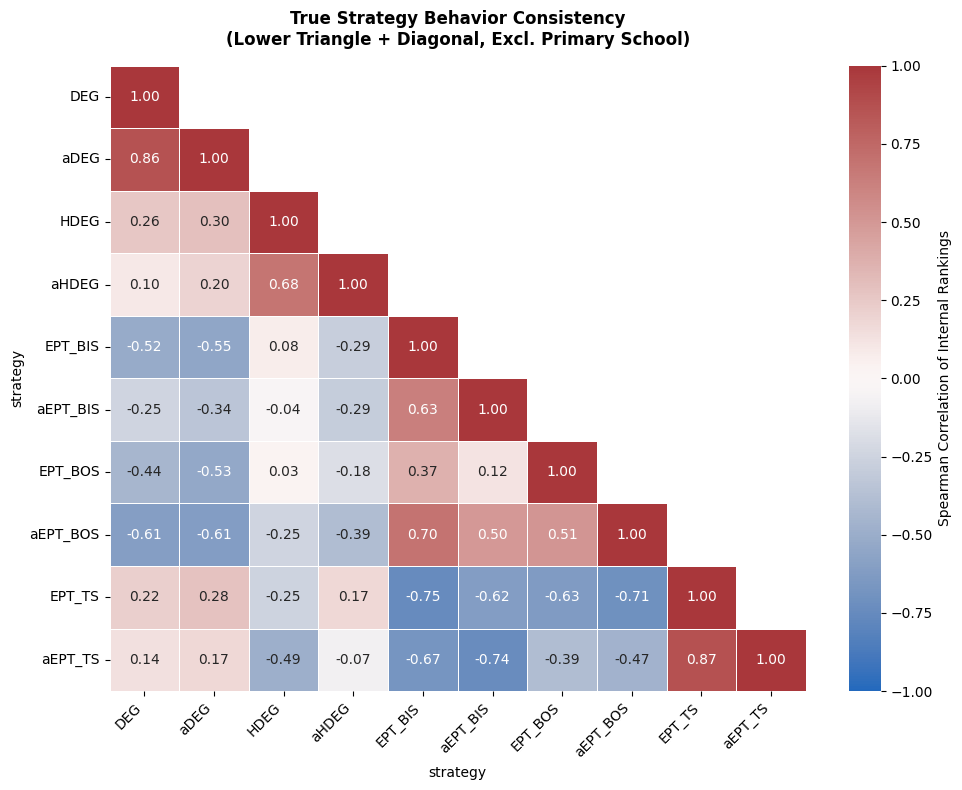

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter data (Ground Truth, stable final timestep, EXCLUDE contact-primary-school)
corr_df = df[
    (df["community_config"] == "ground_truth") & 
    (df["timestep"] == 25) 
    & (df["dataset"] != "contact-primary-school")
].copy()

corr_df["prevalence_pct"] = (corr_df["mean_infected"] / corr_df["remaining_nodes"]) * 100

# 2. Aggregate across simulation runs
agg_df = corr_df.groupby(["dataset", "K", "strategy"])["prevalence_pct"].mean().reset_index()

# 3. Isolate RAND baseline per unique scenario
rand_df = agg_df[agg_df["strategy"] == "RAND"][["dataset", "K", "prevalence_pct"]].rename(
    columns={"prevalence_pct": "rand_prev"}
)

# 4. Compute the relative edge (Infections Prevented)
merged_df = pd.merge(agg_df, rand_df, on=["dataset", "K"])
merged_df["infections_prevented"] = merged_df["rand_prev"] - merged_df["prevalence_pct"]
final_corr_df = merged_df[merged_df["strategy"] != "RAND"].copy()

# 5. Pivot into the Arena Grid
pivot_corr = final_corr_df.pivot(
    index=["dataset", "K"], 
    columns="strategy", 
    values="infections_prevented"
)

# ==============================================================================
# CRITICAL MASTER FIX: Rank strategies 1-10 WITHIN each (dataset, K) sandbox
# ==============================================================================
ranked_pivot = pivot_corr.rank(axis=1, ascending=False)

# 6. Calculate correlation based strictly on competitive placement
strategy_corr = ranked_pivot.corr(method="spearman")

# ==============================================================================
# CUSTOM ORDERING: Grouping Base Strategies with their 'a' Variants
# ==============================================================================
ordered_strategies = [
    'DEG', 'aDEG',
    'HDEG', 'aHDEG',
    'EPT_BIS', 'aEPT_BIS',
    'EPT_BOS', 'aEPT_BOS',
    'EPT_TS', 'aEPT_TS'
]

# Reindex the correlation matrix to enforce this exact order on both axes
strategy_corr = strategy_corr.loc[ordered_strategies, ordered_strategies]

# ==============================================================================
# MASK THE UPPER TRIANGLE (Leaving the diagonal visible)
# ==============================================================================
# Adding k=1 shifts the triangle up by one, leaving the main diagonal unmasked
mask = np.triu(np.ones_like(strategy_corr, dtype=bool), k=1)

# 7. Plot the true competitive heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    strategy_corr, 
    mask=mask,         
    annot=True, // 
    cmap="vlag", 
    fmt=".2f", 
    vmin=-1, vmax=1, 
    linewidths=0.5,
    cbar_kws={"label": "Spearman Correlation of Internal Rankings"}
)

plt.title("True Strategy Behavior Consistency\n(Lower Triangle + Diagonal, Excl. Primary School)", 
          fontsize=12, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10) 
plt.tight_layout()
plt.show()

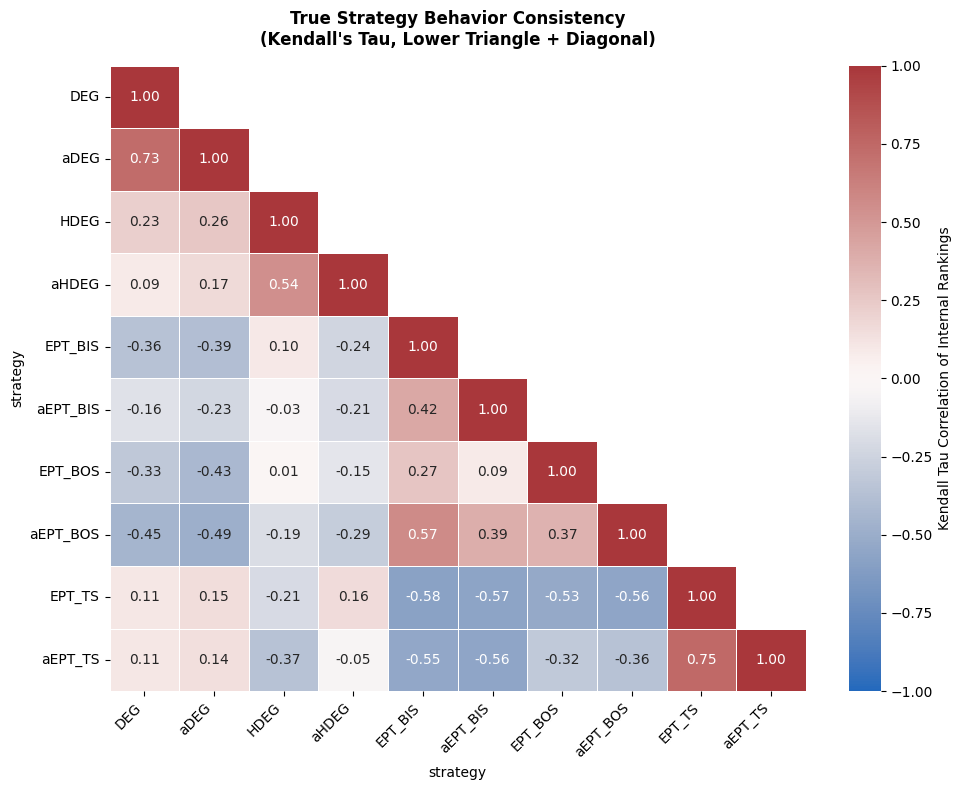

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter data (Ground Truth, stable final timestep, EXCLUDE contact-primary-school)
corr_df = df[
    (df["community_config"] == "ground_truth") & 
    (df["timestep"] == 25) 
    & (df["dataset"] != "contact-primary-school")
].copy()

corr_df["prevalence_pct"] = (corr_df["mean_infected"] / corr_df["remaining_nodes"]) * 100

# 2. Aggregate across simulation runs
agg_df = corr_df.groupby(["dataset", "K", "strategy"])["prevalence_pct"].mean().reset_index()

# 3. Isolate RAND baseline per unique scenario
rand_df = agg_df[agg_df["strategy"] == "RAND"][["dataset", "K", "prevalence_pct"]].rename(
    columns={"prevalence_pct": "rand_prev"}
)

# 4. Compute the relative edge (Infections Prevented)
merged_df = pd.merge(agg_df, rand_df, on=["dataset", "K"])
merged_df["infections_prevented"] = merged_df["rand_prev"] - merged_df["prevalence_pct"]
final_corr_df = merged_df[merged_df["strategy"] != "RAND"].copy()

# 5. Pivot into the Arena Grid
pivot_corr = final_corr_df.pivot(
    index=["dataset", "K"], 
    columns="strategy", 
    values="infections_prevented"
)

# ==============================================================================
# CRITICAL MASTER FIX: Rank strategies 1-10 WITHIN each (dataset, K) sandbox
# ==============================================================================
ranked_pivot = pivot_corr.rank(axis=1, ascending=False)

# 6. Calculate correlation based strictly on competitive placement
# --- Switched to Kendall's Tau ---
strategy_corr = ranked_pivot.corr(method="kendall")

# ==============================================================================
# CUSTOM ORDERING: Grouping Base Strategies with their 'a' Variants
# ==============================================================================
ordered_strategies = [
    'DEG', 'aDEG',
    'HDEG', 'aHDEG',
    'EPT_BIS', 'aEPT_BIS',
    'EPT_BOS', 'aEPT_BOS',
    'EPT_TS', 'aEPT_TS'
]

# Reindex the correlation matrix to enforce this exact order on both axes
strategy_corr = strategy_corr.loc[ordered_strategies, ordered_strategies]

# ==============================================================================
# MASK THE UPPER TRIANGLE (Leaving the diagonal visible)
# ==============================================================================
# Adding k=1 shifts the triangle up by one, leaving the main diagonal unmasked
mask = np.triu(np.ones_like(strategy_corr, dtype=bool), k=1)

# 7. Plot the true competitive heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    strategy_corr, 
    mask=mask,         
    annot=True, 
    cmap="vlag", 
    fmt=".2f", 
    vmin=-1, vmax=1, 
    linewidths=0.5,
    cbar_kws={"label": "Kendall Tau Correlation of Internal Rankings"}
)

plt.title("True Strategy Behavior Consistency\n(Kendall's Tau, Lower Triangle + Diagonal)", 
          fontsize=12, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10) 
plt.tight_layout()
plt.show()